<a href="https://colab.research.google.com/github/JohnFarlander/Omkar-AML-Experiments/blob/main/AML_LCA_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Case study on Market basket analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset Loaded Successfully 
Shape: (38765, 3)

Top 5 Products:
itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
Name: count, dtype: int64


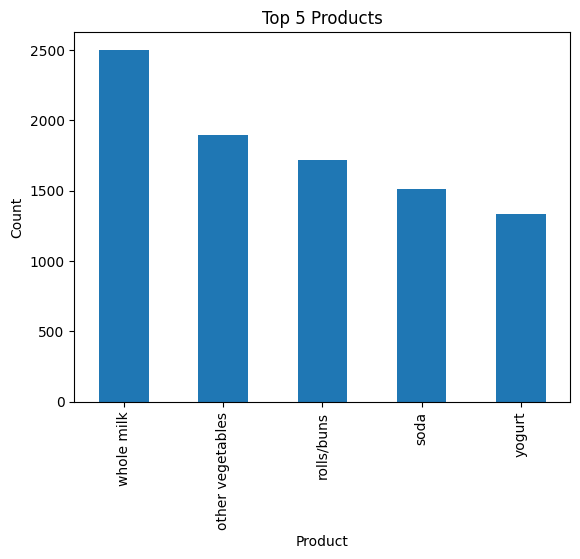


Unique Customers: 3898
Unique Products: 167

Basket Shape: (14963, 167)

Train Size: (11970, 166)
Test Size: (2993, 166)

=== MODEL PERFORMANCE ===
Accuracy: 0.4

Precision (Buy): 0.17
Recall (Buy): 0.77


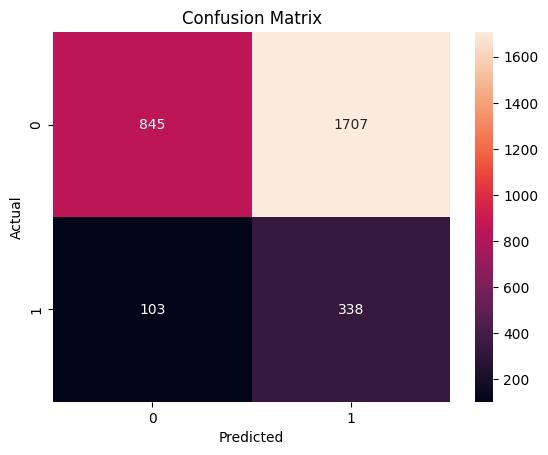


Top 5 Influencing Products:
1. butter milk (0.157)
2. root vegetables (0.125)
3. rolls/buns (0.120)
4. whipped/sour cream (0.111)
5. other vegetables (0.109)

Sample Prediction:
1 = Will Buy, 0 = Will NOT Buy → False


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from mlxtend.preprocessing import TransactionEncoder

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



file_path = '/content/drive/MyDrive/Groceries_dataset.csv'
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ")
print("Shape:", df.shape)



print("\nTop 5 Products:")
top_products = df['itemDescription'].value_counts().head(5)
print(top_products)

# Plot
plt.figure()
top_products.plot(kind='bar')
plt.title("Top 5 Products")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

print("\nUnique Customers:", df['Member_number'].nunique())
print("Unique Products:", df['itemDescription'].nunique())


transactions = df.groupby(['Member_number', 'Date'])['itemDescription'] \
                 .apply(list).values.tolist()


te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

print("\nBasket Shape:", basket.shape)


target_product = 'whole milk'   # you can change if needed

X = basket.drop(columns=[target_product])
y = basket[target_product]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Size:", X_train.shape)
print("Test Size:", X_test.shape)

model = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
model.fit(X_train, y_train)



y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\n=== MODEL PERFORMANCE ===")
print("Accuracy:", round(accuracy, 2))

# Only key metrics
report = classification_report(y_test, y_pred, output_dict=True)
print("\nPrecision (Buy):", round(report['True']['precision'], 2))
print("Recall (Buy):", round(report['True']['recall'], 2))



# 11. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# 12. FEATURE IMPORTANCE (TOP 5)
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(5)

print("\nTop 5 Influencing Products:")
for i, (item, val) in enumerate(top_features.items(), 1):
    print(f"{i}. {item} ({val:.3f})")



# 13. SAMPLE PREDICTION
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)

print("\nSample Prediction:")
print("1 = Will Buy, 0 = Will NOT Buy →", prediction[0])



# import pandas as pd
# from mlxtend.preprocessing import TransactionEncoder
# from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeClassifier

# # Load data
# df = pd.read_csv('/content/drive/MyDrive/Groceries_dataset.csv')

# # Convert to transactions
# transactions = df.groupby(['Member_number','Date'])['itemDescription'].apply(list)

# # Encode
# te = TransactionEncoder()
# basket = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

# # Target
# X = basket.drop(columns=['whole milk'])
# y = basket['whole milk']

# # Model
# X_train, X_test, y_train, y_test = train_test_split(X, y)
# model = DecisionTreeClassifier().fit(X_train, y_train)

# # Output
# print("Accuracy:", model.score(X_test, y_test))